# Movie Dataset

### List of Columns and Desc

- id: A unique ID number of the row. Int64
- imdb_id: An imdb unique ID number. String/Object
- popularity: The movie's popularity rating. Float64
- budget: The movie's budget. Int64
- revenue: The movie's revenue. Int64
- original_title: The movie's title. String/Object
- cast: A list of cast members. String/Object
- homepage: The movie's website. String/Object
- director: The movie's director. String/Object
- tagline: The movie's tagline. String/Object
- keywords: Keywords for searching. String/Object
- overview: A brief synopsis. String/Object
- runtime: Movie runtime in minutes. Int64
- genres: Primary genres that the movie falls under. String/Object
- production_companies: Companies that aided in production. String/Object
- release_date: Date the movie was released. String/Object
- vote_count: Number of votes. Int64
- vote_average: Average of votes. Float64
- release_year: Year the movie was released. Int64
- budget_adj: Adjusted budget in terms of 2010 dollars. Float64
- revenue_adj: Adjusted revenue in terms of 2010 dollars. Float64

### Questions for Analysis:

- What genres profit the most on average?
- Does a higher budget lead to higher revenue?
- How has genre popularity changed over time?
- Which key words are most associated with top grossing films?
-

#### What genres profit the most on average in the 21st Century?

In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv('movie_data.csv')

In [3]:
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

In [5]:
df.drop(columns=["imdb_id", "popularity","homepage","tagline","keywords","vote_count","vote_average","budget_adj","revenue_adj"],inplace=True)

In [6]:
df.head()

,id,budget,revenue,original_title,cast,director,overview,runtime,genres,production_companies,release_date,release_year
0,135397,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,2015
1,76341,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,2015
2,262500,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,Robert Schwentke,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2015
3,140607,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,J.J. Abrams,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,2015
4,168259,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,James Wan,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2015


In [7]:
df.drop(columns=["overview","release_date"],inplace=True)

In [8]:
df.head(2)

,id,budget,revenue,original_title,cast,director,runtime,genres,production_companies,release_year
0,135397,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,2015
1,76341,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,2015


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    10866 non-null  int64 
 1   budget                10866 non-null  int64 
 2   revenue               10866 non-null  int64 
 3   original_title        10866 non-null  object
 4   cast                  10790 non-null  object
 5   director              10822 non-null  object
 6   runtime               10866 non-null  int64 
 7   genres                10843 non-null  object
 8   production_companies  9836 non-null   object
 9   release_year          10866 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 849.0+ KB


In [10]:
df.dropna(inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9773 entries, 0 to 10865
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9773 non-null   int64 
 1   budget                9773 non-null   int64 
 2   revenue               9773 non-null   int64 
 3   original_title        9773 non-null   object
 4   cast                  9773 non-null   object
 5   director              9773 non-null   object
 6   runtime               9773 non-null   int64 
 7   genres                9773 non-null   object
 8   production_companies  9773 non-null   object
 9   release_year          9773 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 839.9+ KB


In [12]:
df = df[df["release_year"] > 1999]

In [13]:
df["genres"] = df["genres"].str.split("|")

In [14]:
df["genres"] = df["genres"].str[0]

In [15]:
df.head()

,id,budget,revenue,original_title,cast,director,runtime,genres,production_companies,release_year
0,135397,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action,Universal Studios|Amblin Entertainment|Legenda...,2015
1,76341,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,120,Action,Village Roadshow Pictures|Kennedy Miller Produ...,2015
2,262500,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,Robert Schwentke,119,Adventure,Summit Entertainment|Mandeville Films|Red Wago...,2015
3,140607,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,J.J. Abrams,136,Action,Lucasfilm|Truenorth Productions|Bad Robot,2015
4,168259,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,James Wan,137,Action,Universal Pictures|Original Film|Media Rights ...,2015


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6268 entries, 0 to 8885
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    6268 non-null   int64 
 1   budget                6268 non-null   int64 
 2   revenue               6268 non-null   int64 
 3   original_title        6268 non-null   object
 4   cast                  6268 non-null   object
 5   director              6268 non-null   object
 6   runtime               6268 non-null   int64 
 7   genres                6268 non-null   object
 8   production_companies  6268 non-null   object
 9   release_year          6268 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 538.7+ KB


In [17]:
df["release_year"] = df["release_year"].astype("int16")

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6268 entries, 0 to 8885
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    6268 non-null   int64 
 1   budget                6268 non-null   int64 
 2   revenue               6268 non-null   int64 
 3   original_title        6268 non-null   object
 4   cast                  6268 non-null   object
 5   director              6268 non-null   object
 6   runtime               6268 non-null   int64 
 7   genres                6268 non-null   object
 8   production_companies  6268 non-null   object
 9   release_year          6268 non-null   int16 
dtypes: int16(1), int64(4), object(5)
memory usage: 501.9+ KB


In [19]:
df.head(2)

,id,budget,revenue,original_title,cast,director,runtime,genres,production_companies,release_year
0,135397,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action,Universal Studios|Amblin Entertainment|Legenda...,2015
1,76341,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,120,Action,Village Roadshow Pictures|Kennedy Miller Produ...,2015


In [20]:
import numpy as np

In [21]:
np.iinfo(np.int16)

iinfo(min=-32768, max=32767, dtype=int16)

In [22]:
df["runtime"].max()

np.int64(877)

In [23]:
df["runtime"] = df["runtime"].astype("int16")

In [24]:
df.head(2)

,id,budget,revenue,original_title,cast,director,runtime,genres,production_companies,release_year
0,135397,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action,Universal Studios|Amblin Entertainment|Legenda...,2015
1,76341,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,120,Action,Village Roadshow Pictures|Kennedy Miller Produ...,2015


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6268 entries, 0 to 8885
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    6268 non-null   int64 
 1   budget                6268 non-null   int64 
 2   revenue               6268 non-null   int64 
 3   original_title        6268 non-null   object
 4   cast                  6268 non-null   object
 5   director              6268 non-null   object
 6   runtime               6268 non-null   int16 
 7   genres                6268 non-null   object
 8   production_companies  6268 non-null   object
 9   release_year          6268 non-null   int16 
dtypes: int16(2), int64(3), object(5)
memory usage: 465.2+ KB


In [26]:
df["id"].max()

np.int64(417859)

In [27]:
np.iinfo(np.int32)

iinfo(min=-2147483648, max=2147483647, dtype=int32)

In [28]:
df["id"] = df["id"].astype("int32")

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6268 entries, 0 to 8885
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    6268 non-null   int32 
 1   budget                6268 non-null   int64 
 2   revenue               6268 non-null   int64 
 3   original_title        6268 non-null   object
 4   cast                  6268 non-null   object
 5   director              6268 non-null   object
 6   runtime               6268 non-null   int16 
 7   genres                6268 non-null   object
 8   production_companies  6268 non-null   object
 9   release_year          6268 non-null   int16 
dtypes: int16(2), int32(1), int64(2), object(5)
memory usage: 440.7+ KB


In [30]:
pd.set_option("display.float_format","{:.2f}".format)

In [31]:
# creating movie profit column 
df["profit"] = df["revenue"] - df["budget"]

In [32]:
# aggregating genres by mean profit and count of movies
df.groupby(by="genres")["profit"].agg(["mean","count"]).sort_values(by="mean",ascending=False)

,mean,count
genres,,
Adventure,112964248.46,314
Science Fiction,71109153.88,122
Animation,63634210.94,281
Fantasy,60483019.79,131
Action,51386596.85,853
Family,50940974.78,89
War,35786358.73,37
History,31418137.50,26
Romance,22409145.72,110


In [33]:
df.groupby("original_title")["profit"].min().sort_values()

original_title
The Warrior's Way               -413912431
The Lone Ranger                 -165710090
The Wolfman                     -150000000
The Pacific                     -120000000
The Alamo                       -119180039
                                   ...    
The Avengers                    1299557910
Furious 7                       1316249360
Jurassic World                  1363528810
Star Wars: The Force Awakens    1868178225
Avatar                          2544505847
Name: profit, Length: 6207, dtype: int64

In [34]:
df[df["budget"] == 0]

,id,budget,revenue,original_title,cast,director,runtime,genres,production_companies,release_year,profit
30,280996,0,29355203,Mr. Holmes,Ian McKellen|Milo Parker|Laura Linney|Hattie M...,Bill Condon,103,Mystery,BBC Films|See-Saw Films|FilmNation Entertainme...,2015,29355203
36,339527,0,22354572,Solace,Abbie Cornish|Jeffrey Dean Morgan|Colin Farrel...,Afonso Poyart,101,Crime,Eden Rock Media|FilmNation Entertainment|Flynn...,2015,22354572
72,284289,0,45895,Beyond the Reach,Michael Douglas|Jeremy Irvine|Hanna Mangan Law...,Jean-Baptiste LÃ©onetti,95,Thriller,Furthur Films,2015,45895
74,347096,0,0,Mythica: The Darkspore,Melanie Stone|Kevin Sorbo|Adam Johnson|Jake St...,Anne K. Black,108,Action,Arrowstorm Entertainment,2015,0
75,308369,0,0,Me and Earl and the Dying Girl,Thomas Mann|RJ Cyler|Olivia Cooke|Connie Britt...,Alfonso Gomez-Rejon,105,Comedy,Indian Paintbrush,2015,0
...,...,...,...,...,...,...,...,...,...,...,...
8872,60587,0,0,The Audrey Hepburn Story,Jennifer Love Hewitt|Frances Fisher|Eric McCor...,Steven Robman,133,Drama,Robert Greenwald Productions|Endemol Entertain...,2000,0
8873,36380,0,0,Chlopaki nie placza,Cezary Pazura|Maciej Stuhr|MichaÅ‚ Milowicz|Bo...,Olaf Lubaszenko,90,Comedy,Agencja Produkcji Filmowej|Canal+ Polska|Best ...,2000,0
8876,21991,0,0,State and Main,Alec Baldwin|Philip Seymour Hoffman|William H....,David Mamet,102,Comedy,Filmtown Entertainment Group|El Dorado Picture...,2000,0
8882,32536,0,0,Rejected,Robert May|Don Hertzfeldt|Jennifer Nyholm,Don Hertzfeldt,9,Animation,Bitter Films,2000,0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6268 entries, 0 to 8885
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    6268 non-null   int32 
 1   budget                6268 non-null   int64 
 2   revenue               6268 non-null   int64 
 3   original_title        6268 non-null   object
 4   cast                  6268 non-null   object
 5   director              6268 non-null   object
 6   runtime               6268 non-null   int16 
 7   genres                6268 non-null   object
 8   production_companies  6268 non-null   object
 9   release_year          6268 non-null   int16 
 10  profit                6268 non-null   int64 
dtypes: int16(2), int32(1), int64(3), object(5)
memory usage: 489.7+ KB


In [36]:
df = df[df["budget"] > 0]

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3262 entries, 0 to 8883
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    3262 non-null   int32 
 1   budget                3262 non-null   int64 
 2   revenue               3262 non-null   int64 
 3   original_title        3262 non-null   object
 4   cast                  3262 non-null   object
 5   director              3262 non-null   object
 6   runtime               3262 non-null   int16 
 7   genres                3262 non-null   object
 8   production_companies  3262 non-null   object
 9   release_year          3262 non-null   int16 
 10  profit                3262 non-null   int64 
dtypes: int16(2), int32(1), int64(3), object(5)
memory usage: 254.8+ KB


In [38]:
df.groupby("genres")["profit"].mean().sort_values(ascending=False)

genres
Adventure         167380219.90
Animation         157749646.20
Family            134911473.70
Science Fiction   125715498.35
Fantasy           103142787.97
Action             74750323.10
War                66204763.65
History            56889337.64
Romance            46658900.48
Comedy             40065984.46
Music              34270124.10
Thriller           29425988.17
Horror             26005568.68
Drama              25501232.05
Crime              24090221.92
Western            23611155.83
Mystery            17829950.47
Documentary        14284047.81
TV Movie           -3625000.00
Name: profit, dtype: float64

In [39]:
df.columns

Index(['id', 'budget', 'revenue', 'original_title', 'cast', 'director',
       'runtime', 'genres', 'production_companies', 'release_year', 'profit'],
      dtype='object')

In [40]:
df.rename({"id":"movie_id", "genres":"primary_genre", "original_title": "title"})

,id,budget,revenue,original_title,cast,director,runtime,genres,production_companies,release_year,profit
0,135397,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action,Universal Studios|Amblin Entertainment|Legenda...,2015,1363528810
1,76341,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,120,Action,Village Roadshow Pictures|Kennedy Miller Produ...,2015,228436354
2,262500,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,Robert Schwentke,119,Adventure,Summit Entertainment|Mandeville Films|Red Wago...,2015,185238201
3,140607,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,J.J. Abrams,136,Action,Lucasfilm|Truenorth Productions|Bad Robot,2015,1868178225
4,168259,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,James Wan,137,Action,Universal Pictures|Original Film|Media Rights ...,2015,1316249360
...,...,...,...,...,...,...,...,...,...,...,...
8866,17711,76000000,35134820,The Adventures of Rocky & Bullwinkle,Rene Russo|Jason Alexander|Piper Perabo|Randy ...,Des McAnuff,88,Adventure,Universal Pictures|Capella International|KC Me...,2000,-40865180
8868,15723,7000000,3728888,The Big Kahuna,Kevin Spacey|Danny DeVito|Peter Facinelli|Paul...,John Swanbeck,90,Comedy,Franchise Pictures|Trigger Street Productions,2000,-3271112
8870,21355,57000000,0,All the Pretty Horses,Matt Damon|Henry Thomas|PenÃ©lope Cruz|Sam She...,Billy Bob Thornton,117,Drama,Columbia Pictures|Miramax Films,2000,-57000000
8881,10385,40000000,36037909,Hanging Up,Meg Ryan|Diane Keaton|Lisa Kudrow|Walter Matth...,Diane Keaton,94,Comedy,Laurence Mark Productions|Columbia Pictures Co...,2000,-3962091


In [41]:
df["production_companies"] = df["production_companies"].str.split("|").str[0]

In [42]:
df.head()

,id,budget,revenue,original_title,cast,director,runtime,genres,production_companies,release_year,profit
0,135397,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action,Universal Studios,2015,1363528810
1,76341,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,120,Action,Village Roadshow Pictures,2015,228436354
2,262500,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,Robert Schwentke,119,Adventure,Summit Entertainment,2015,185238201
3,140607,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,J.J. Abrams,136,Action,Lucasfilm,2015,1868178225
4,168259,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,James Wan,137,Action,Universal Pictures,2015,1316249360


In [43]:
df.rename({"production_companies":"company"})

,id,budget,revenue,original_title,cast,director,runtime,genres,production_companies,release_year,profit
0,135397,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action,Universal Studios,2015,1363528810
1,76341,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,120,Action,Village Roadshow Pictures,2015,228436354
2,262500,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,Robert Schwentke,119,Adventure,Summit Entertainment,2015,185238201
3,140607,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,J.J. Abrams,136,Action,Lucasfilm,2015,1868178225
4,168259,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,James Wan,137,Action,Universal Pictures,2015,1316249360
...,...,...,...,...,...,...,...,...,...,...,...
8866,17711,76000000,35134820,The Adventures of Rocky & Bullwinkle,Rene Russo|Jason Alexander|Piper Perabo|Randy ...,Des McAnuff,88,Adventure,Universal Pictures,2000,-40865180
8868,15723,7000000,3728888,The Big Kahuna,Kevin Spacey|Danny DeVito|Peter Facinelli|Paul...,John Swanbeck,90,Comedy,Franchise Pictures,2000,-3271112
8870,21355,57000000,0,All the Pretty Horses,Matt Damon|Henry Thomas|PenÃ©lope Cruz|Sam She...,Billy Bob Thornton,117,Drama,Columbia Pictures,2000,-57000000
8881,10385,40000000,36037909,Hanging Up,Meg Ryan|Diane Keaton|Lisa Kudrow|Walter Matth...,Diane Keaton,94,Comedy,Laurence Mark Productions,2000,-3962091


In [44]:
df.sample(2)

,id,budget,revenue,original_title,cast,director,runtime,genres,production_companies,release_year,profit
3422,49021,66000000,57777106,Killer Elite,Jason Statham|Clive Owen|Robert De Niro|Domini...,Gary McKendry,116,Action,Current Entertainment,2011,-8222894
776,169298,3000000,0,Bullet,Danny Trejo|Seri DeYoung|Torsten Voges|Jonatha...,Nick Lyon,87,Action,Giant Ape Media,2014,-3000000


In [45]:
df["lead_act"] = df["cast"].str.split("|").str[0]

In [46]:
df.head(2)

,id,budget,revenue,original_title,cast,director,runtime,genres,production_companies,release_year,profit,lead_act
0,135397,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action,Universal Studios,2015,1363528810,Chris Pratt
1,76341,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,120,Action,Village Roadshow Pictures,2015,228436354,Tom Hardy


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3262 entries, 0 to 8883
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    3262 non-null   int32 
 1   budget                3262 non-null   int64 
 2   revenue               3262 non-null   int64 
 3   original_title        3262 non-null   object
 4   cast                  3262 non-null   object
 5   director              3262 non-null   object
 6   runtime               3262 non-null   int16 
 7   genres                3262 non-null   object
 8   production_companies  3262 non-null   object
 9   release_year          3262 non-null   int16 
 10  profit                3262 non-null   int64 
 11  lead_act              3262 non-null   object
dtypes: int16(2), int32(1), int64(3), object(6)
memory usage: 409.4+ KB


In [48]:
df.drop(columns="cast",inplace=True)

In [49]:
df.head(1)

,id,budget,revenue,original_title,director,runtime,genres,production_companies,release_year,profit,lead_act
0,135397,150000000,1513528810,Jurassic World,Colin Trevorrow,124,Action,Universal Studios,2015,1363528810,Chris Pratt


In [50]:
profit_over_time = df.groupby(["release_year", "genres"])["profit"].mean().unstack()

<Axes: xlabel='release_year'>

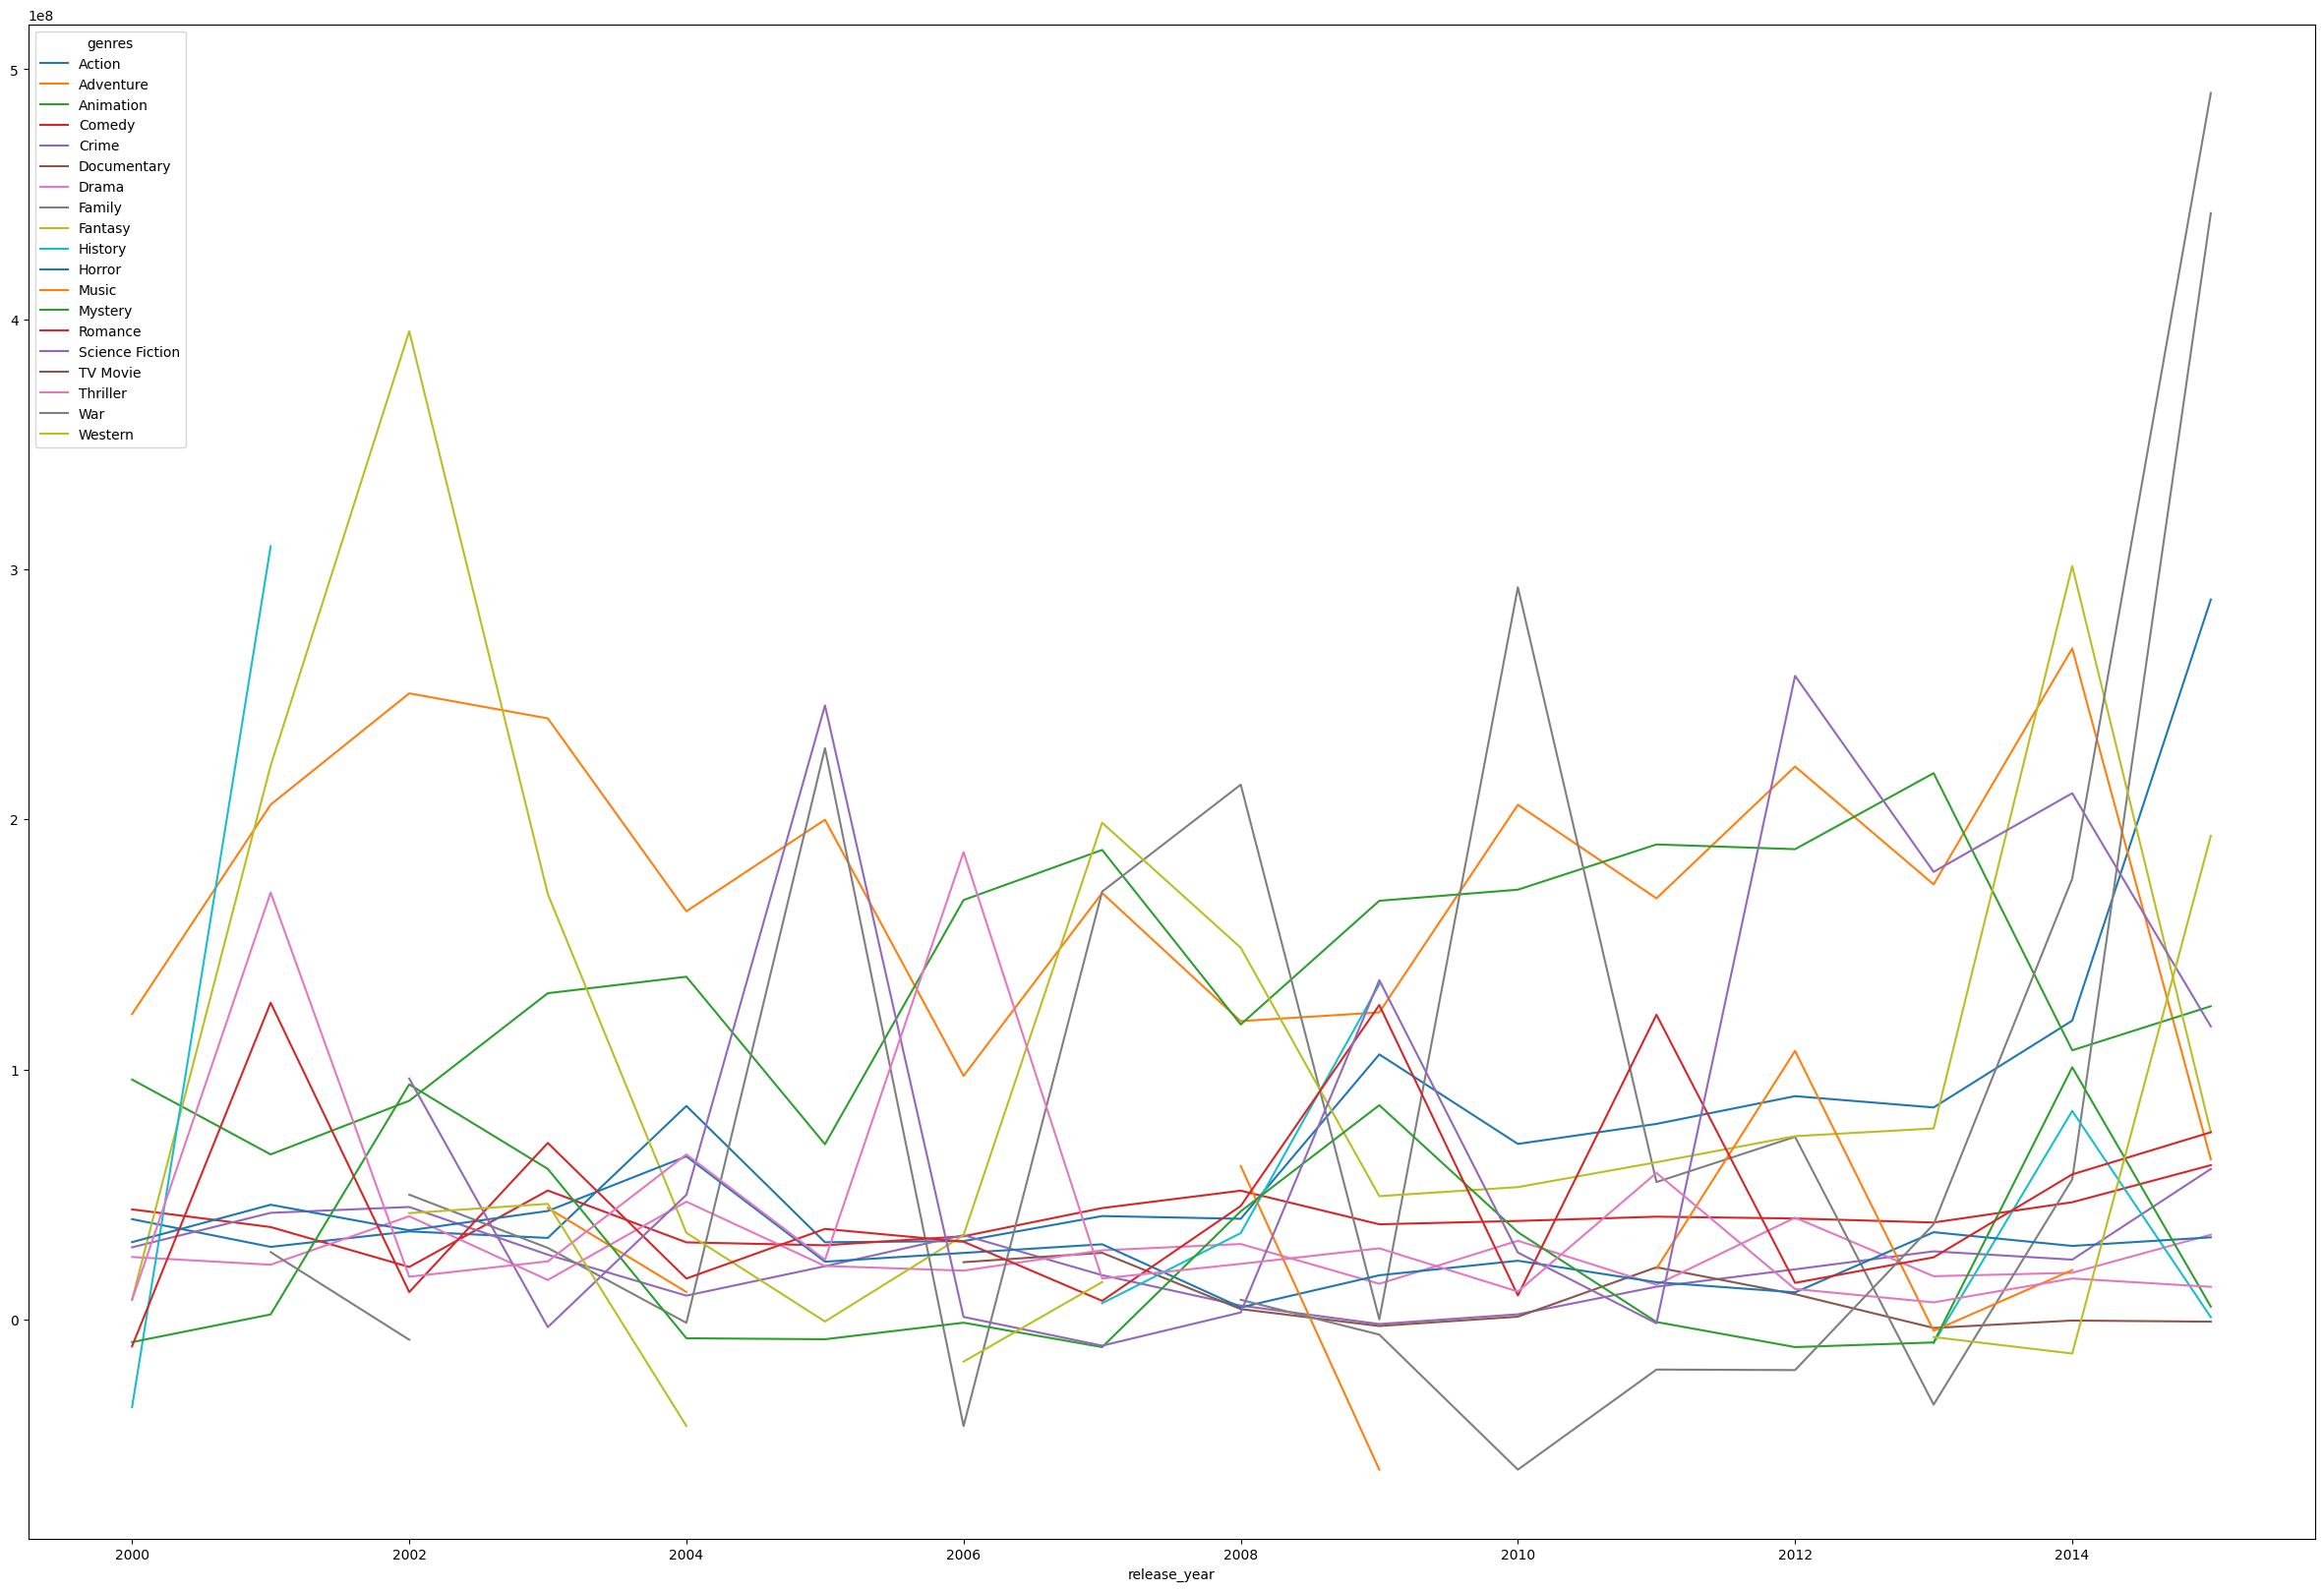

In [51]:
profit_over_time.plot(kind="line", figsize=(30,20))

In [52]:
df.groupby("genres")["profit"].agg(["mean","count"]).sort_values(by="mean",ascending=False)

,mean,count
genres,,
Adventure,167380219.90,210
Animation,157749646.20,112
Family,134911473.70,33
Science Fiction,125715498.35,69
Fantasy,103142787.97,74
Action,74750323.10,574
War,66204763.65,20
History,56889337.64,14
Romance,46658900.48,52


#### In the 21st century, the highest profiting genre on average is adventure. As you can see, there are many more action and comedy movies than there are adventure. I may break this down further and take the highest profiting movies to match the sample sizes between comedy, adventure, drama, horror, and action (movies with the highest counts).

#### Of this sample of movies, how does budget correlate with revenue and/or profit? Which leading cast members produced the most profit on average? Is there a correlation between leading actor/acctress and profit? Is there a correlation between runtime and profit? Production company and profit?

In [54]:
df.head()

,id,budget,revenue,original_title,director,runtime,genres,production_companies,release_year,profit,lead_act
0,135397,150000000,1513528810,Jurassic World,Colin Trevorrow,124,Action,Universal Studios,2015,1363528810,Chris Pratt
1,76341,150000000,378436354,Mad Max: Fury Road,George Miller,120,Action,Village Roadshow Pictures,2015,228436354,Tom Hardy
2,262500,110000000,295238201,Insurgent,Robert Schwentke,119,Adventure,Summit Entertainment,2015,185238201,Shailene Woodley
3,140607,200000000,2068178225,Star Wars: The Force Awakens,J.J. Abrams,136,Action,Lucasfilm,2015,1868178225,Harrison Ford
4,168259,190000000,1506249360,Furious 7,James Wan,137,Action,Universal Pictures,2015,1316249360,Vin Diesel


In [55]:
df.to_csv('clean_movies.csv')

In [56]:
df_clean = pd.read_csv('clean_movies.csv')

In [64]:
# Highest profiting lead cast on average
highest_profiting_acts = df_clean.groupby('lead_act')["profit"].mean().sort_values(ascending=False)

In [65]:
highest_profiting_acts.head(5)

lead_act
Chris Pratt       983420604.50
John Leguizamo    782244782.00
Albert Brooks     770625978.00
Amy Poehler       678708609.00
William Moseley   568806957.00
Name: profit, dtype: float64

In [66]:
# Max profit lead cast
df_clean.groupby('lead_act')["profit"].max().sort_values(ascending=False)

lead_act
Sam Worthington      2544505847
Harrison Ford        1868178225
Chris Pratt          1363528810
Vin Diesel           1316249360
Robert Downey Jr.    1299557910
                        ...    
Heike Makatsch        -74010360
French Stewart        -80000000
Jamie Kennedy         -84000000
Tia Mowry            -104002432
James Badge Dale     -120000000
Name: profit, Length: 1363, dtype: int64

In [67]:
highest_profit_companies = df_clean.groupby('production_companies')["profit"].mean().sort_values(ascending=False)

In [68]:
highest_profit_companies.head()

production_companies
Cool Music                       788212738.00
Lucasfilm                        759199086.00
Patalex IV Productions Limited   745921036.00
WingNut Films                    598157032.89
1492 Pictures                    593136834.25
Name: profit, dtype: float64

In [69]:
df_clean.groupby('production_companies')["profit"].max().sort_values(ascending=False)

production_companies
Ingenious Film Partners          2544505847
Lucasfilm                        1868178225
Universal Studios                1363528810
Universal Pictures               1316249360
Marvel Studios                   1299557910
                                    ...    
Overbrook Films                   -65000000
Vnesheconombank                   -73821041
Imprint Entertainment             -83000000
Jaffe / Braunstein Enterprise    -104002432
Boram Entertainment Inc.         -413912431
Name: profit, Length: 1070, dtype: int64

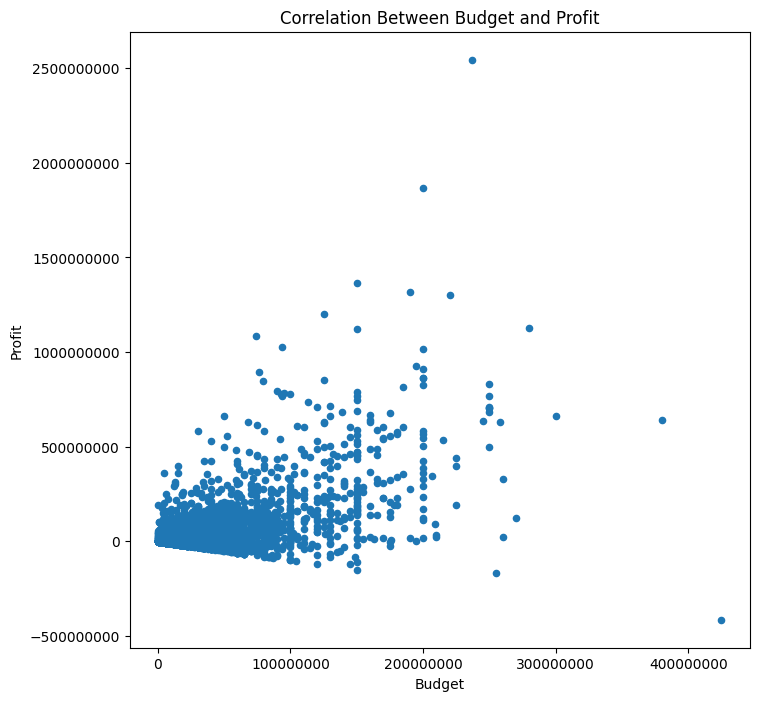

In [73]:
import matplotlib.pyplot as plt 
df_clean.plot(kind="scatter",figsize=(8,8),x="budget",y="profit",xlabel="Budget",ylabel="Profit",title="Correlation Between Budget and Profit")

plt.ticklabel_format(style="plain",axis="x")
plt.ticklabel_format(style="plain",axis="y")

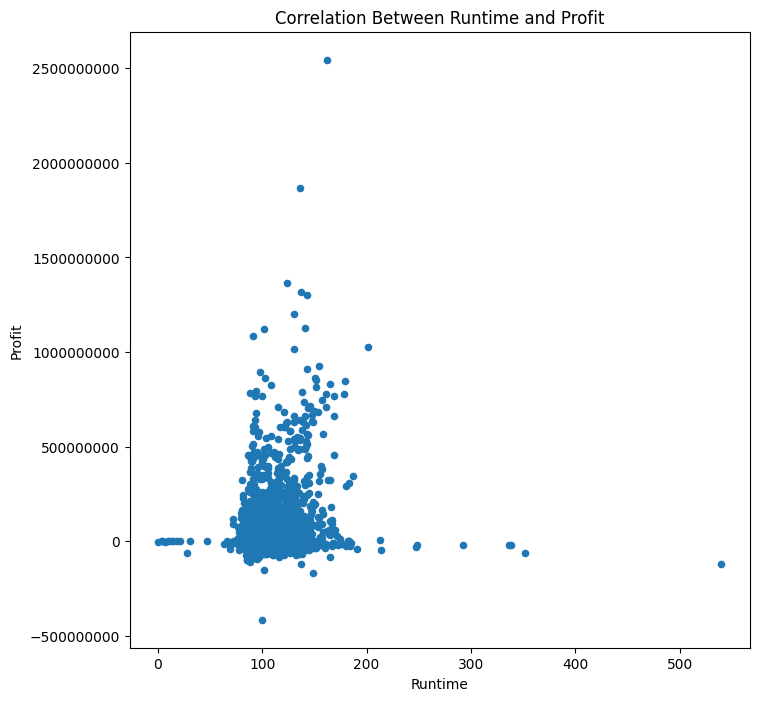

In [75]:
df_clean.plot(kind="scatter",figsize=(8,8),x="runtime",y="profit",xlabel="Runtime",ylabel="Profit",title="Correlation Between Runtime and Profit")

plt.ticklabel_format(style="plain",axis="x")
plt.ticklabel_format(style="plain",axis="y")